<a href="https://colab.research.google.com/github/apirakqqqqq/Ge338_Lab4/blob/main/Lab_4_6606614870_%E0%B8%AD%E0%B8%A0%E0%B8%B4%E0%B8%A3%E0%B8%B1%E0%B8%81%E0%B8%A9%E0%B9%8C_%E0%B8%9B%E0%B8%B1%E0%B8%8D%E0%B8%8D%E0%B8%B2%E0%B8%AA%E0%B8%B2%E0%B8%84%E0%B8%A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install geopandas rasterio folium shapely matplotlib -q

import rasterio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


นำเข้าข้อมูล

In [4]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# 🔧 แก้ path ให้ตรงของคุณ
base = "/content/drive/MyDrive/LAB4/"

elev = rasterio.open(base + "Songkhla_Elevation.tif").read(1)
slope = rasterio.open(base + "Songkhla_Slope.tif").read(1)
rain = rasterio.open(base + "Songkhla_Rainfall.tif").read(1)
water = rasterio.open(base + "Songkhla_WaterDistance.tif").read(1)
land = rasterio.open(base + "Songkhla_LandCover.tif").read(1)

Normoalize

In [5]:
def normalize(arr):
    return (arr - np.nanmin(arr)) / (np.nanmax(arr) - np.nanmin(arr))

# Elevation (ต่ำ = เสี่ยงสูง)
elev_norm = 1 - normalize(elev)

# Slope (ต่ำ = เสี่ยงสูง)
slope_norm = 1 - normalize(slope)

# Rainfall (มาก = เสี่ยงสูง)
rain_norm = normalize(rain)

# Distance to water (ใกล้ = เสี่ยงสูง)
water_norm = 1 - normalize(water)

# Land cover (normalize)
land_norm = normalize(land)

ค่าของแต่ละปัจจัยถูกปรับให้อยู่ในช่วง 0–1 โดยใช้วิธี min-max normalization เพื่อให้สามารถนำมารวมกันในโมเดลได้ เนื่องจากแต่ละปัจจัยมีหน่วยและช่วงค่าที่แตกต่างกัน โดยกำหนดให้ค่าที่สูงแทนความเสี่ยงสูง เช่น พื้นที่ที่มีความสูงต่ำและอยู่ใกล้แหล่งน้ำถูกปรับให้มีค่าความเสี่ยงสูง

In [6]:
from rasterio.enums import Resampling

# ใช้ elevation เป็น reference
ref = rasterio.open(base + "Songkhla_Elevation.tif")

def resample_to_ref(path):
    with rasterio.open(path) as src:
        data = src.read(
            out_shape=(1, ref.height, ref.width),
            resampling=Resampling.bilinear
        )[0]
    return data

rain = resample_to_ref(base + "Songkhla_Rainfall.tif")
water = resample_to_ref(base + "Songkhla_WaterDistance.tif")
land = resample_to_ref(base + "Songkhla_LandCover.tif")

rain_norm = normalize(rain)
water_norm = 1 - normalize(water)
land_norm = normalize(land)

Align / Resample เพราะ resolution ไม่เท่ากัน ต้องทำการ combine ก่อน

In [7]:
flood = (
    (0.30 * elev_norm) +
    (0.25 * rain_norm) +
    (0.20 * water_norm) +
    (0.15 * slope_norm) +
    (0.10 * land_norm)
)

โมเดลนี้ใช้วิธี Weighted Linear Combination โดยกำหนดน้ำหนักให้แต่ละปัจจัยตามความสำคัญ โดย Elevation มีน้ำหนักสูงสุดเนื่องจากเป็นตัวกำหนดการไหลของน้ำ รองลงมาคือ Rainfall ซึ่งเป็นตัวกระตุ้นการเกิดน้ำท่วม ส่วน Distance to Water, Slope และ Land Cover มีผลรองลงมาตามลำดับ

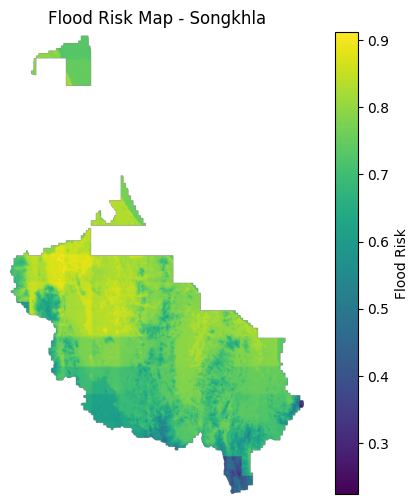

In [8]:
plt.figure(figsize=(8,6))
plt.imshow(flood)
plt.colorbar(label='Flood Risk')
plt.title('Flood Risk Map - Songkhla')
plt.axis('off')
plt.show()

พื้นที่ว่าง (NoData) ที่ปรากฏในแผนที่เกิดจากความไม่สอดคล้องของขอบเขตและความละเอียดเชิงพื้นที่ของข้อมูลแต่ละปัจจัย ทำให้บางพิกเซลไม่มีข้อมูลครบสำหรับการคำนวณ ขณะที่ผลลัพธ์โดยรวมแสดงให้เห็นว่าพื้นที่เสี่ยงน้ำท่วมสูงกระจุกตัวในบริเวณพื้นที่ราบต่ำและระบายน้ำไม่ดี ส่วนพื้นที่เสี่ยงต่ำอยู่ในบริเวณที่มีความสูงและความลาดชันมากกว่า ซึ่งสอดคล้องกับลักษณะภูมิประเทศของพื้นที่ศึกษา

Export Flood Base(รวมโค้ดก่อนหน้าทั้งหมดแล้ว Export)

In [9]:
import numpy as np
import rasterio
from rasterio.enums import Resampling

# =========================
# 1. PATH
# =========================
base_path = "/content/drive/MyDrive/LAB4/"

# =========================
# 2. โหลด reference
# =========================
with rasterio.open(base_path + "Songkhla_Elevation.tif") as ref:
    ref_data = ref.read(1)
    ref_profile = ref.profile

# =========================
# 3. ฟังก์ชัน resample
# =========================
def load_match(path):
    with rasterio.open(path) as src:
        data = src.read(
            1,
            out_shape=(ref_profile["height"], ref_profile["width"]),
            resampling=Resampling.bilinear
        )
    return data

# =========================
# 4. โหลดข้อมูล
# =========================
elev = load_match(base_path + "Songkhla_Elevation.tif")
slope = load_match(base_path + "Songkhla_Slope.tif")
rain = load_match(base_path + "Songkhla_Rainfall.tif")
water = load_match(base_path + "Songkhla_WaterDistance.tif")
land = load_match(base_path + "Songkhla_LandCover.tif")

# =========================
# 5. Normalize
# =========================
def norm(x):
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x) + 1e-9)

elev_n = 1 - norm(elev)
slope_n = 1 - norm(slope)
rain_n = norm(rain)
water_n = 1 - norm(water)
land_n = norm(land)

# =========================
# 6. Flood Model
# =========================
flood_base = (
    0.30 * elev_n +
    0.25 * rain_n +
    0.20 * water_n +
    0.15 * slope_n +
    0.10 * land_n
)

print("✅ flood_base created:", flood_base.shape)

# =========================
# 7. Export
# =========================
output_path = base_path + "Flood_Base.tif"

with rasterio.open(
    output_path,
    "w",
    driver="GTiff",
    height=flood_base.shape[0],
    width=flood_base.shape[1],
    count=1,
    dtype=flood_base.dtype,
    crs=ref_profile["crs"],
    transform=ref_profile["transform"],
) as dst:
    dst.write(flood_base, 1)

print("✅ Exported:", output_path)

✅ flood_base created: (6132, 3898)
✅ Exported: /content/drive/MyDrive/LAB4/Flood_Base.tif


# **ลองเปลี่ยนน้ำหนักของปัจจัยที่สำคัญที่สุด ±20%**

In [10]:
# baseline
flood_base = (
    (0.30 * elev_norm) +
    (0.25 * rain_norm) +
    (0.20 * water_norm) +
    (0.15 * slope_norm) +
    (0.10 * land_norm)
)

# +20% elevation
flood_high = (
    (0.36 * elev_norm) +
    (0.23 * rain_norm) +
    (0.18 * water_norm) +
    (0.14 * slope_norm) +
    (0.09 * land_norm)
)

# -20% elevation
flood_low = (
    (0.24 * elev_norm) +
    (0.27 * rain_norm) +
    (0.22 * water_norm) +
    (0.16 * slope_norm) +
    (0.11 * land_norm)
)

diff_high = flood_high - flood_base
diff_low = flood_low - flood_base

แสดงผล

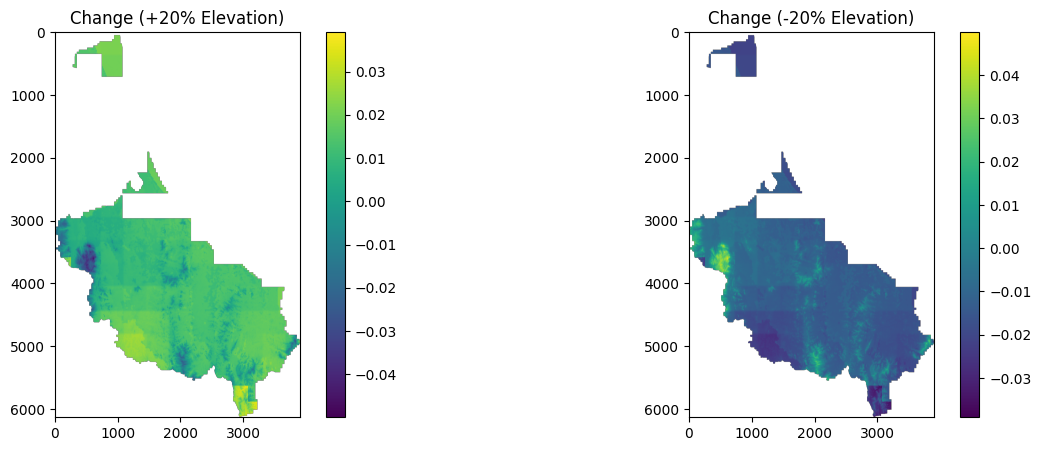

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.imshow(diff_high)
plt.title("Change (+20% Elevation)")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(diff_low)
plt.title("Change (-20% Elevation)")
plt.colorbar()

plt.show()

Interactive Map


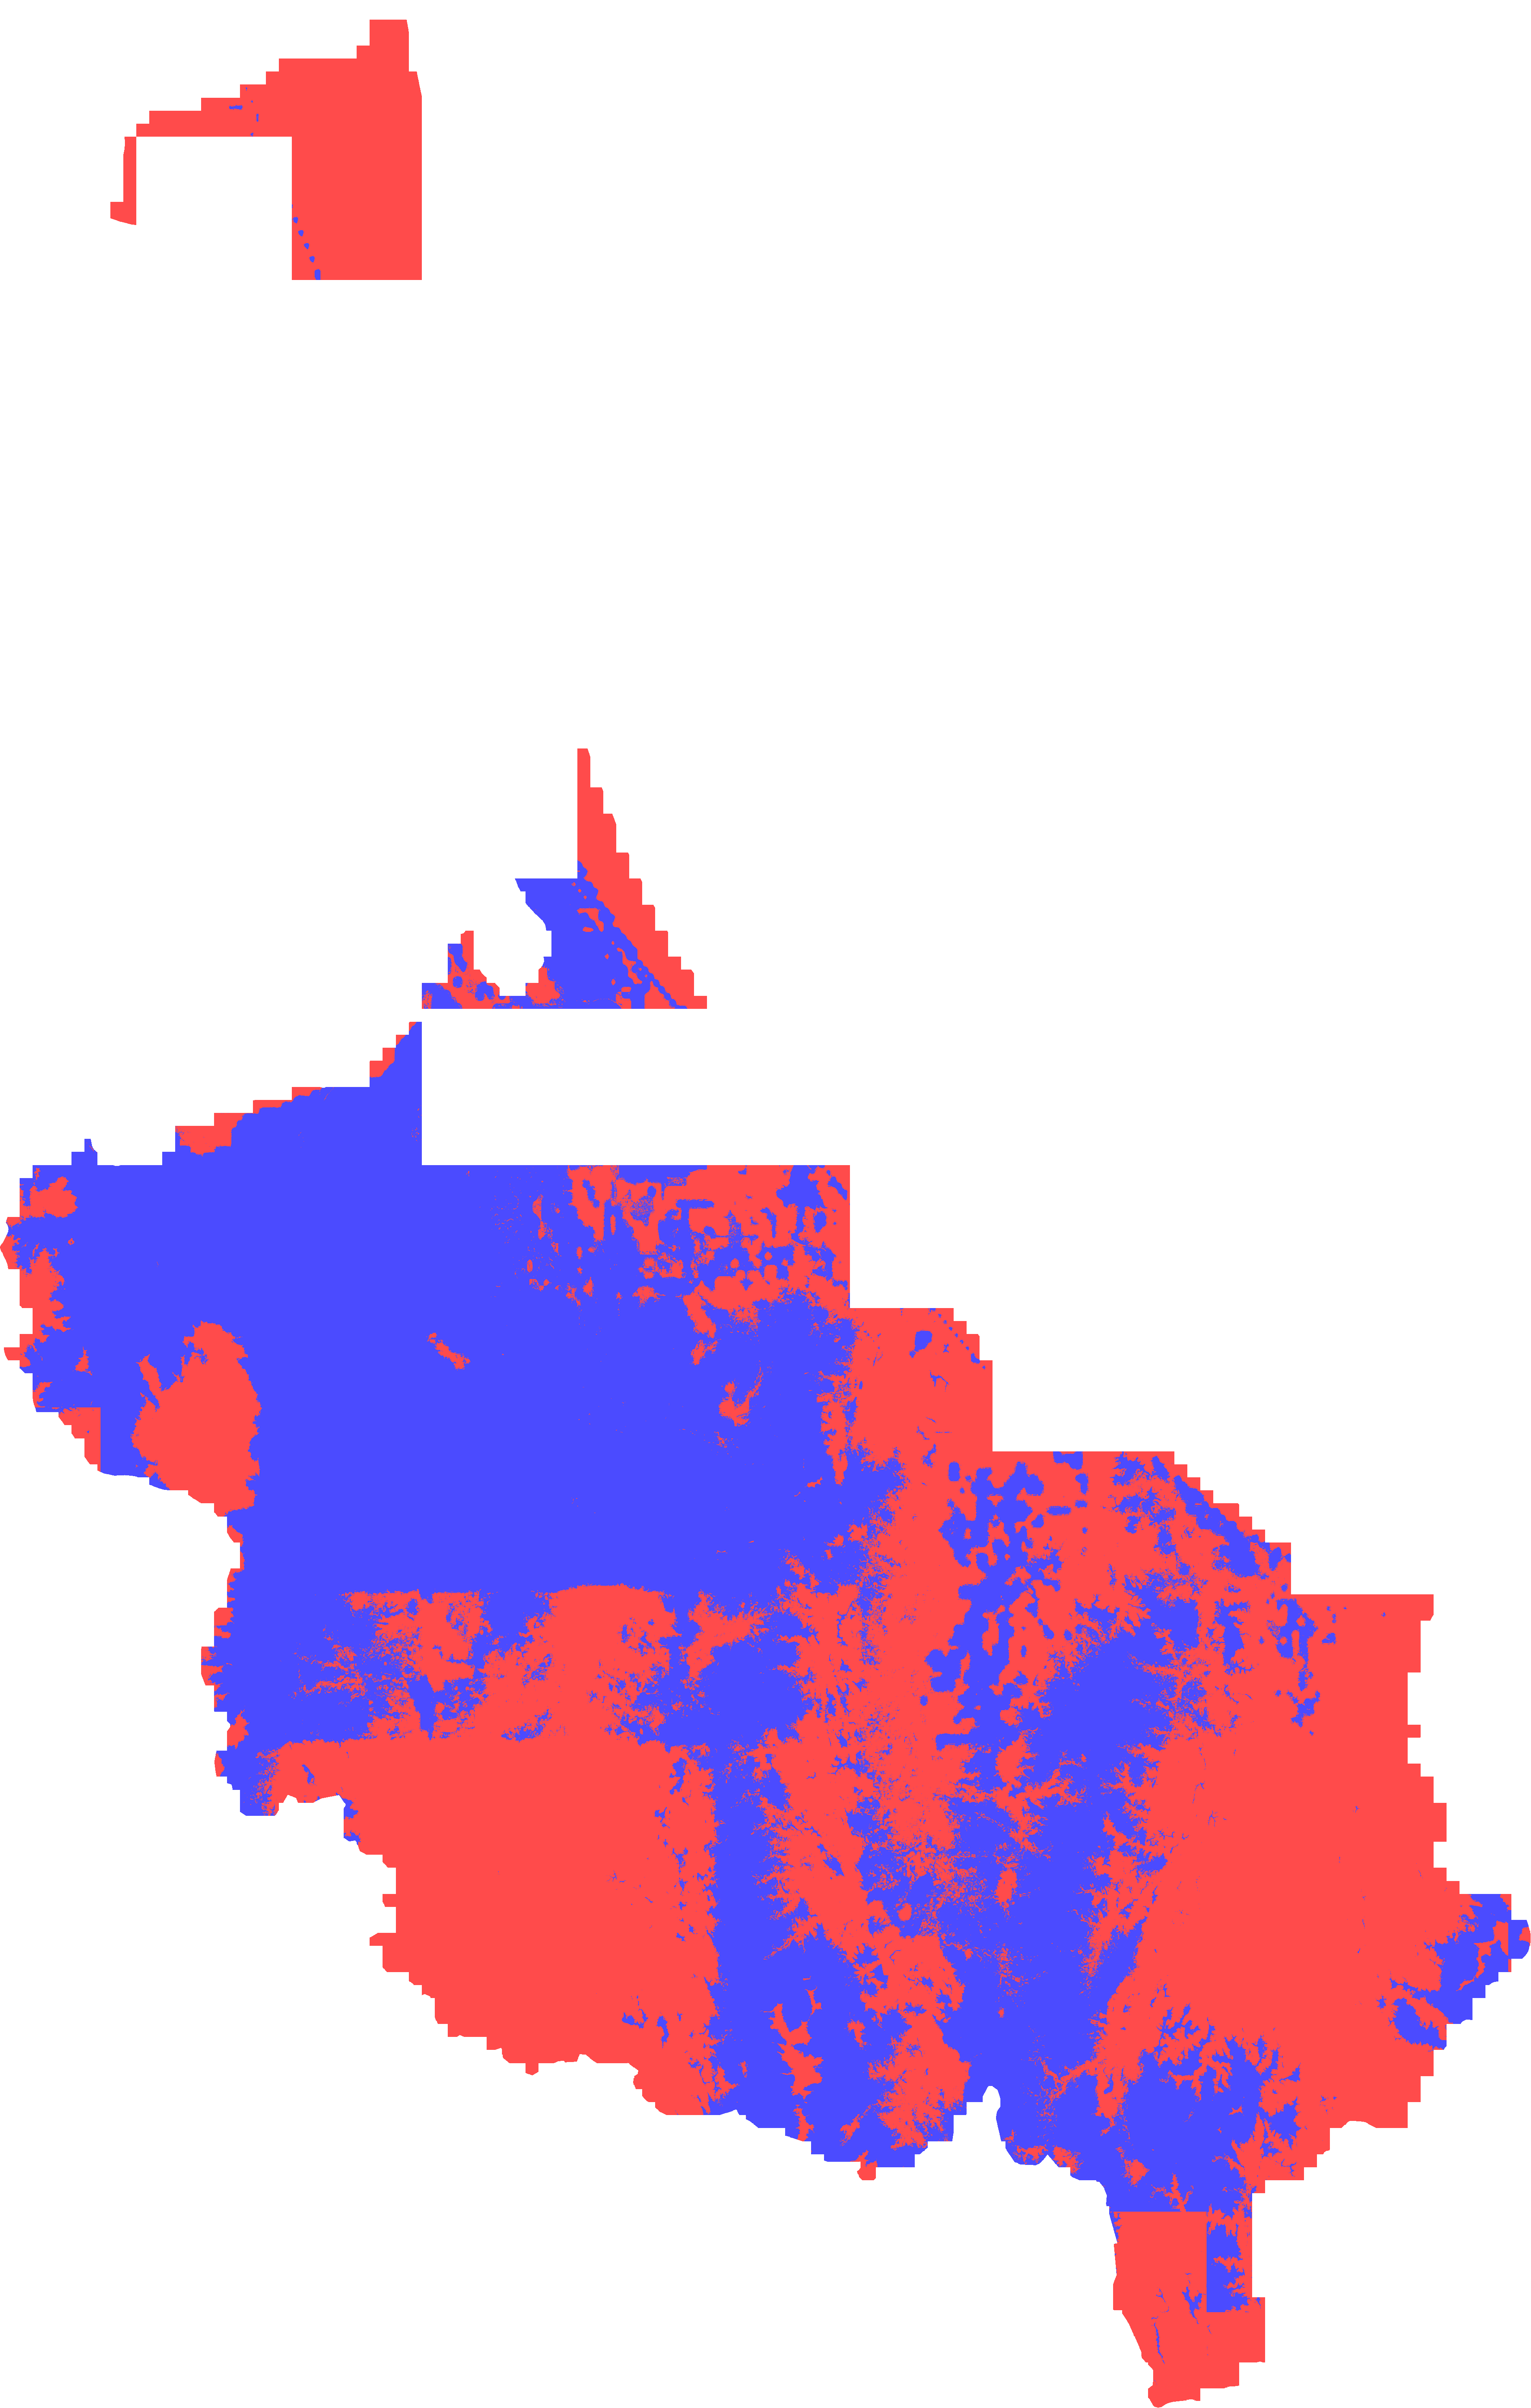

In [12]:
import folium
base_path = "/content/drive/MyDrive/LAB4/"

# =========================
# 2. Reference Raster
# =========================
with rasterio.open(base_path + "Songkhla_Elevation.tif") as ref:
    ref_data = ref.read(1)
    ref_profile = ref.profile
    bounds = ref.bounds

mask = np.isfinite(ref_data)

# =========================
# 3. Resample Function
# =========================
def load_match(path):
    with rasterio.open(path) as src:
        data = src.read(
            1,
            out_shape=(ref_profile["height"], ref_profile["width"]),
            resampling=Resampling.bilinear
        )
    return data

# =========================
# 4. Load Data
# =========================
elev = load_match(base_path + "Songkhla_Elevation.tif")
slope = load_match(base_path + "Songkhla_Slope.tif")
rain = load_match(base_path + "Songkhla_Rainfall.tif")
water = load_match(base_path + "Songkhla_WaterDistance.tif")
land = load_match(base_path + "Songkhla_LandCover.tif")

# =========================
# 5. Normalize
# =========================
def norm(x):
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x) + 1e-9)

elev_n = 1 - norm(elev)
slope_n = 1 - norm(slope)
rain_n = norm(rain)
water_n = 1 - norm(water)
land_n = norm(land)

# =========================
# 6. Model
# =========================
flood_base = (
    0.30 * elev_n +
    0.25 * rain_n +
    0.20 * water_n +
    0.15 * slope_n +
    0.10 * land_n
)

flood_high = (
    0.36 * elev_n +
    0.23 * rain_n +
    0.18 * water_n +
    0.14 * slope_n +
    0.09 * land_n
)

# =========================
# 7. Sensitivity
# =========================
diff = np.abs(flood_high - flood_base)
threshold = np.nanmean(diff)

result = np.full(diff.shape, np.nan)
result[diff < threshold] = 1   # Robust
result[diff >= threshold] = 2  # Sensitive

# ใช้ mask ตัดพื้นที่
result[~mask] = np.nan

# =========================
# 8. แปลงเป็น RGBA (แก้กรอบดำ)
# =========================
rgba = np.zeros((result.shape[0], result.shape[1], 4), dtype=np.uint8)

# Robust = น้ำเงิน
rgba[result == 1] = [0, 0, 255, 180]

# Sensitive = แดง
rgba[result == 2] = [255, 0, 0, 180]

# ❗ พื้นที่นอก = โปร่งใส
rgba[np.isnan(result)] = [0, 0, 0, 0]

# =========================
# 9. Interactive Map
# =========================
minx, miny, maxx, maxy = bounds

center_lat = (miny + maxy) / 2
center_lon = (minx + maxx) / 2

m = folium.Map(location=[center_lat, center_lon], zoom_start=9)

folium.raster_layers.ImageOverlay(
    image=rgba,
    bounds=[[miny, minx], [maxy, maxx]],
).add_to(m)

# =========================
# 10. Legend
# =========================
legend_html = '''
<div style="
position: fixed;
bottom: 50px; left: 50px; width: 180px; height: 90px;
background-color: white; z-index:9999; font-size:14px;
border:2px solid grey; padding: 10px;
">
<b>Sensitivity Map</b><br>
<span style="color:blue;">■</span> Robust (คงที่)<br>
<span style="color:red;">■</span> Sensitive (ไม่แน่นอน)
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

m

In [13]:
m.save("Sensitivity_Map.html")

แผนที่นี้แสดงให้เห็นว่าพื้นที่ที่มีความคงที่ของโมเดลกระจายอยู่ในบริเวณที่มีลักษณะภูมิประเทศชัดเจน ขณะที่พื้นที่ที่มีความไม่แน่นอนมักอยู่ในบริเวณรอยต่อของปัจจัย ซึ่งมีความไวต่อการเปลี่ยนแปลงของน้ำหนักในโมเดล

แปลงเป็น น้ำท่วม / ไม่ท่วม

In [14]:
model_flood = flood_base > 0.75

# **Validation**

โหลดข้อมูล

In [15]:
import numpy as np
import rasterio
from rasterio.enums import Resampling

base_path = "/content/drive/MyDrive/LAB4/"
flood_path = base_path + "Flood_Base.tif"
jrc_path = base_path + "JRC_Occurrence_Songkhla.tif"

# ฟังก์ชันสำคัญ (คุณขาดตัวนี้)
def load_match(path, ref_shape):
    with rasterio.open(path) as src:
        data = src.read(
            1,
            out_shape=ref_shape,
            resampling=Resampling.bilinear
        )
    return data

In [16]:
with rasterio.open(flood_path) as ref:
    flood_base = ref.read(1)
    ref_profile = ref.profile

# 🔥 แก้ตรงนี้ (ต้องใส่ shape)
jrc = load_match(jrc_path, flood_base.shape)

threshold

In [17]:
threshold = np.nanpercentile(flood_base, 80)
model_flood = flood_base > threshold

jrc_flood = jrc > 70

Mask

In [18]:
mask = np.isfinite(flood_base) & np.isfinite(jrc)

model_flood = model_flood[mask]
jrc_flood = jrc_flood[mask]

Confusion Matrix

In [19]:
tp = np.sum((model_flood == 1) & (jrc_flood == 1))
tn = np.sum((model_flood == 0) & (jrc_flood == 0))
fp = np.sum((model_flood == 1) & (jrc_flood == 0))
fn = np.sum((model_flood == 0) & (jrc_flood == 1))

Accuracy

In [20]:
accuracy = (tp + tn) / (tp + tn + fp + fn)

print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("Accuracy:", accuracy)

TP: 19410
TN: 5736984
FP: 1424159
FN: 37293
Accuracy: 0.7975224187382219


ค่า Accuracy เท่ากับ 0.80 แสดงว่าโมเดลสามารถจำแนกพื้นที่น้ำท่วมและไม่ท่วมได้ถูกต้องในระดับค่อนข้างดี โดยเฉพาะในพื้นที่ไม่ท่วมที่มีจำนวนมาก (True Negative สูง) อย่างไรก็ตาม โมเดลยังมีแนวโน้มประเมินน้ำท่วมเกินจริงในบางพื้นที่ (False Positive สูง) และยังพลาดการตรวจจับน้ำท่วมจริงบางส่วน (False Negative) จึงควรพิจารณาค่าความคลาดเคลื่อนอื่นร่วมด้วยเพื่อประเมินประสิทธิภาพของโมเดลอย่างครบถ้วน

Compare

In [21]:
compare = np.zeros_like(flood_base)

compare[(flood_base > threshold) & (jrc > 50)] = 1
compare[(flood_base <= threshold) & (jrc <= 50)] = 2
compare[(flood_base > threshold) & (jrc <= 50)] = 3
compare[(flood_base <= threshold) & (jrc > 50)] = 4

แสดงผล


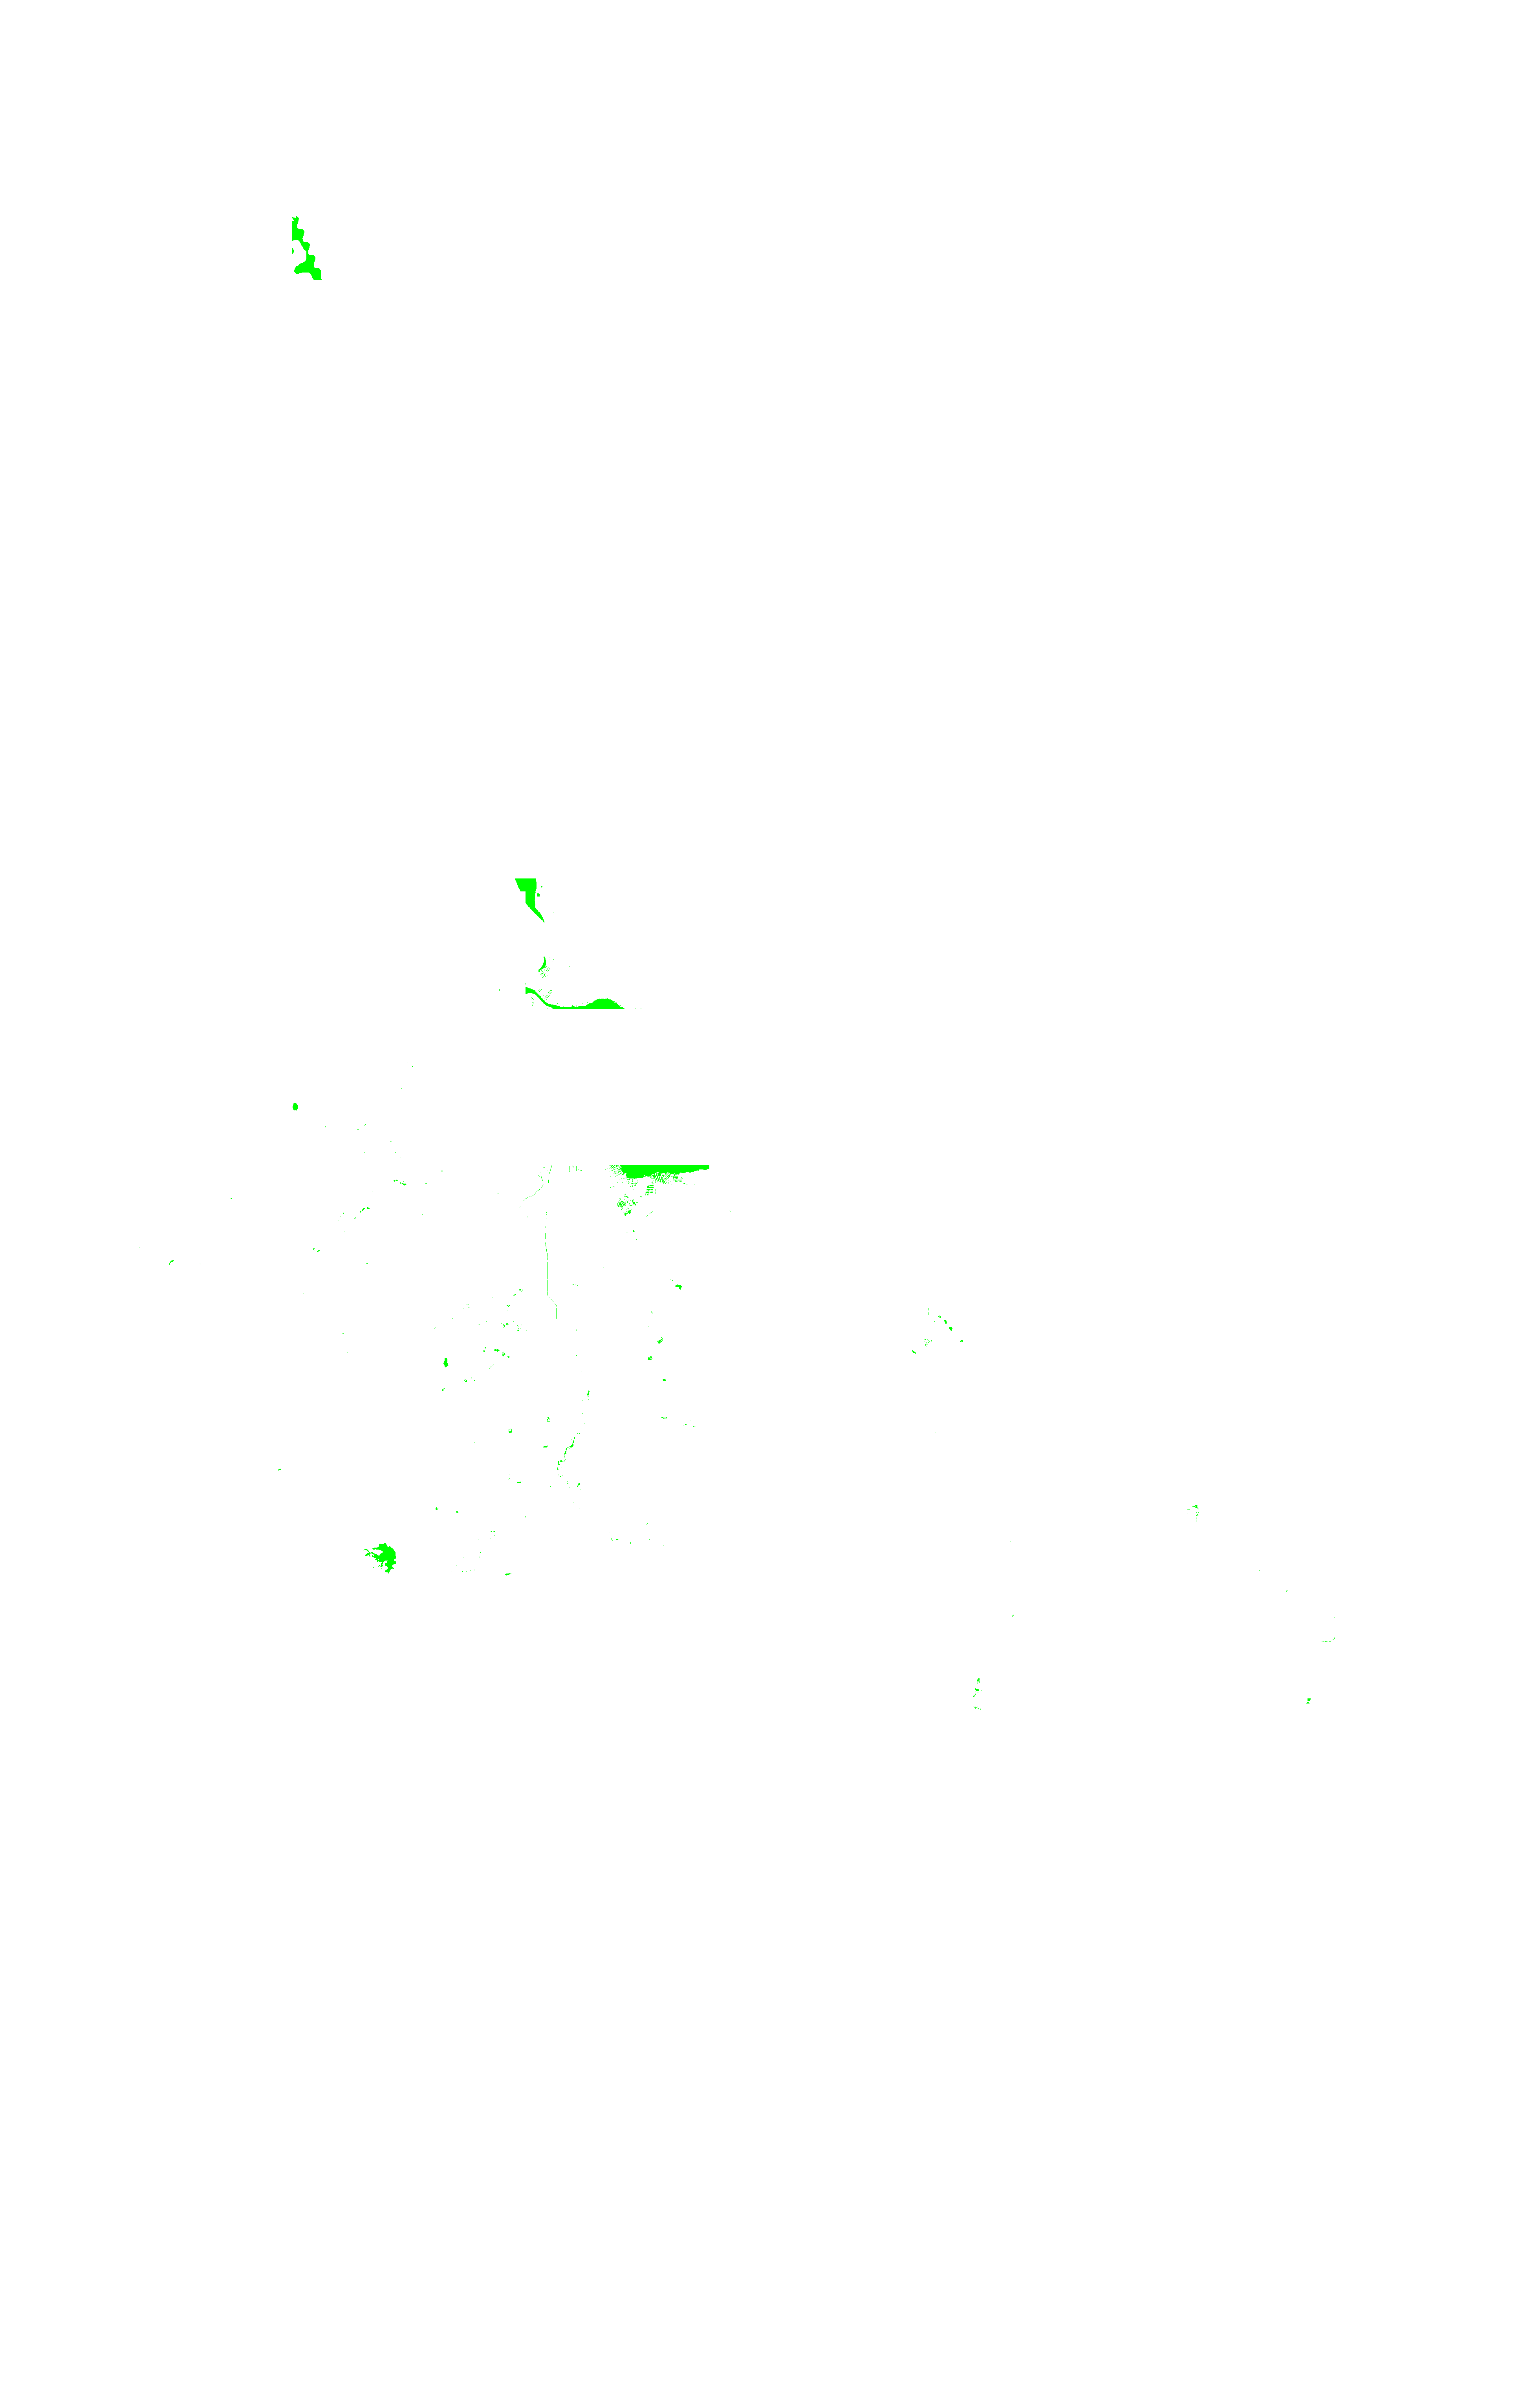
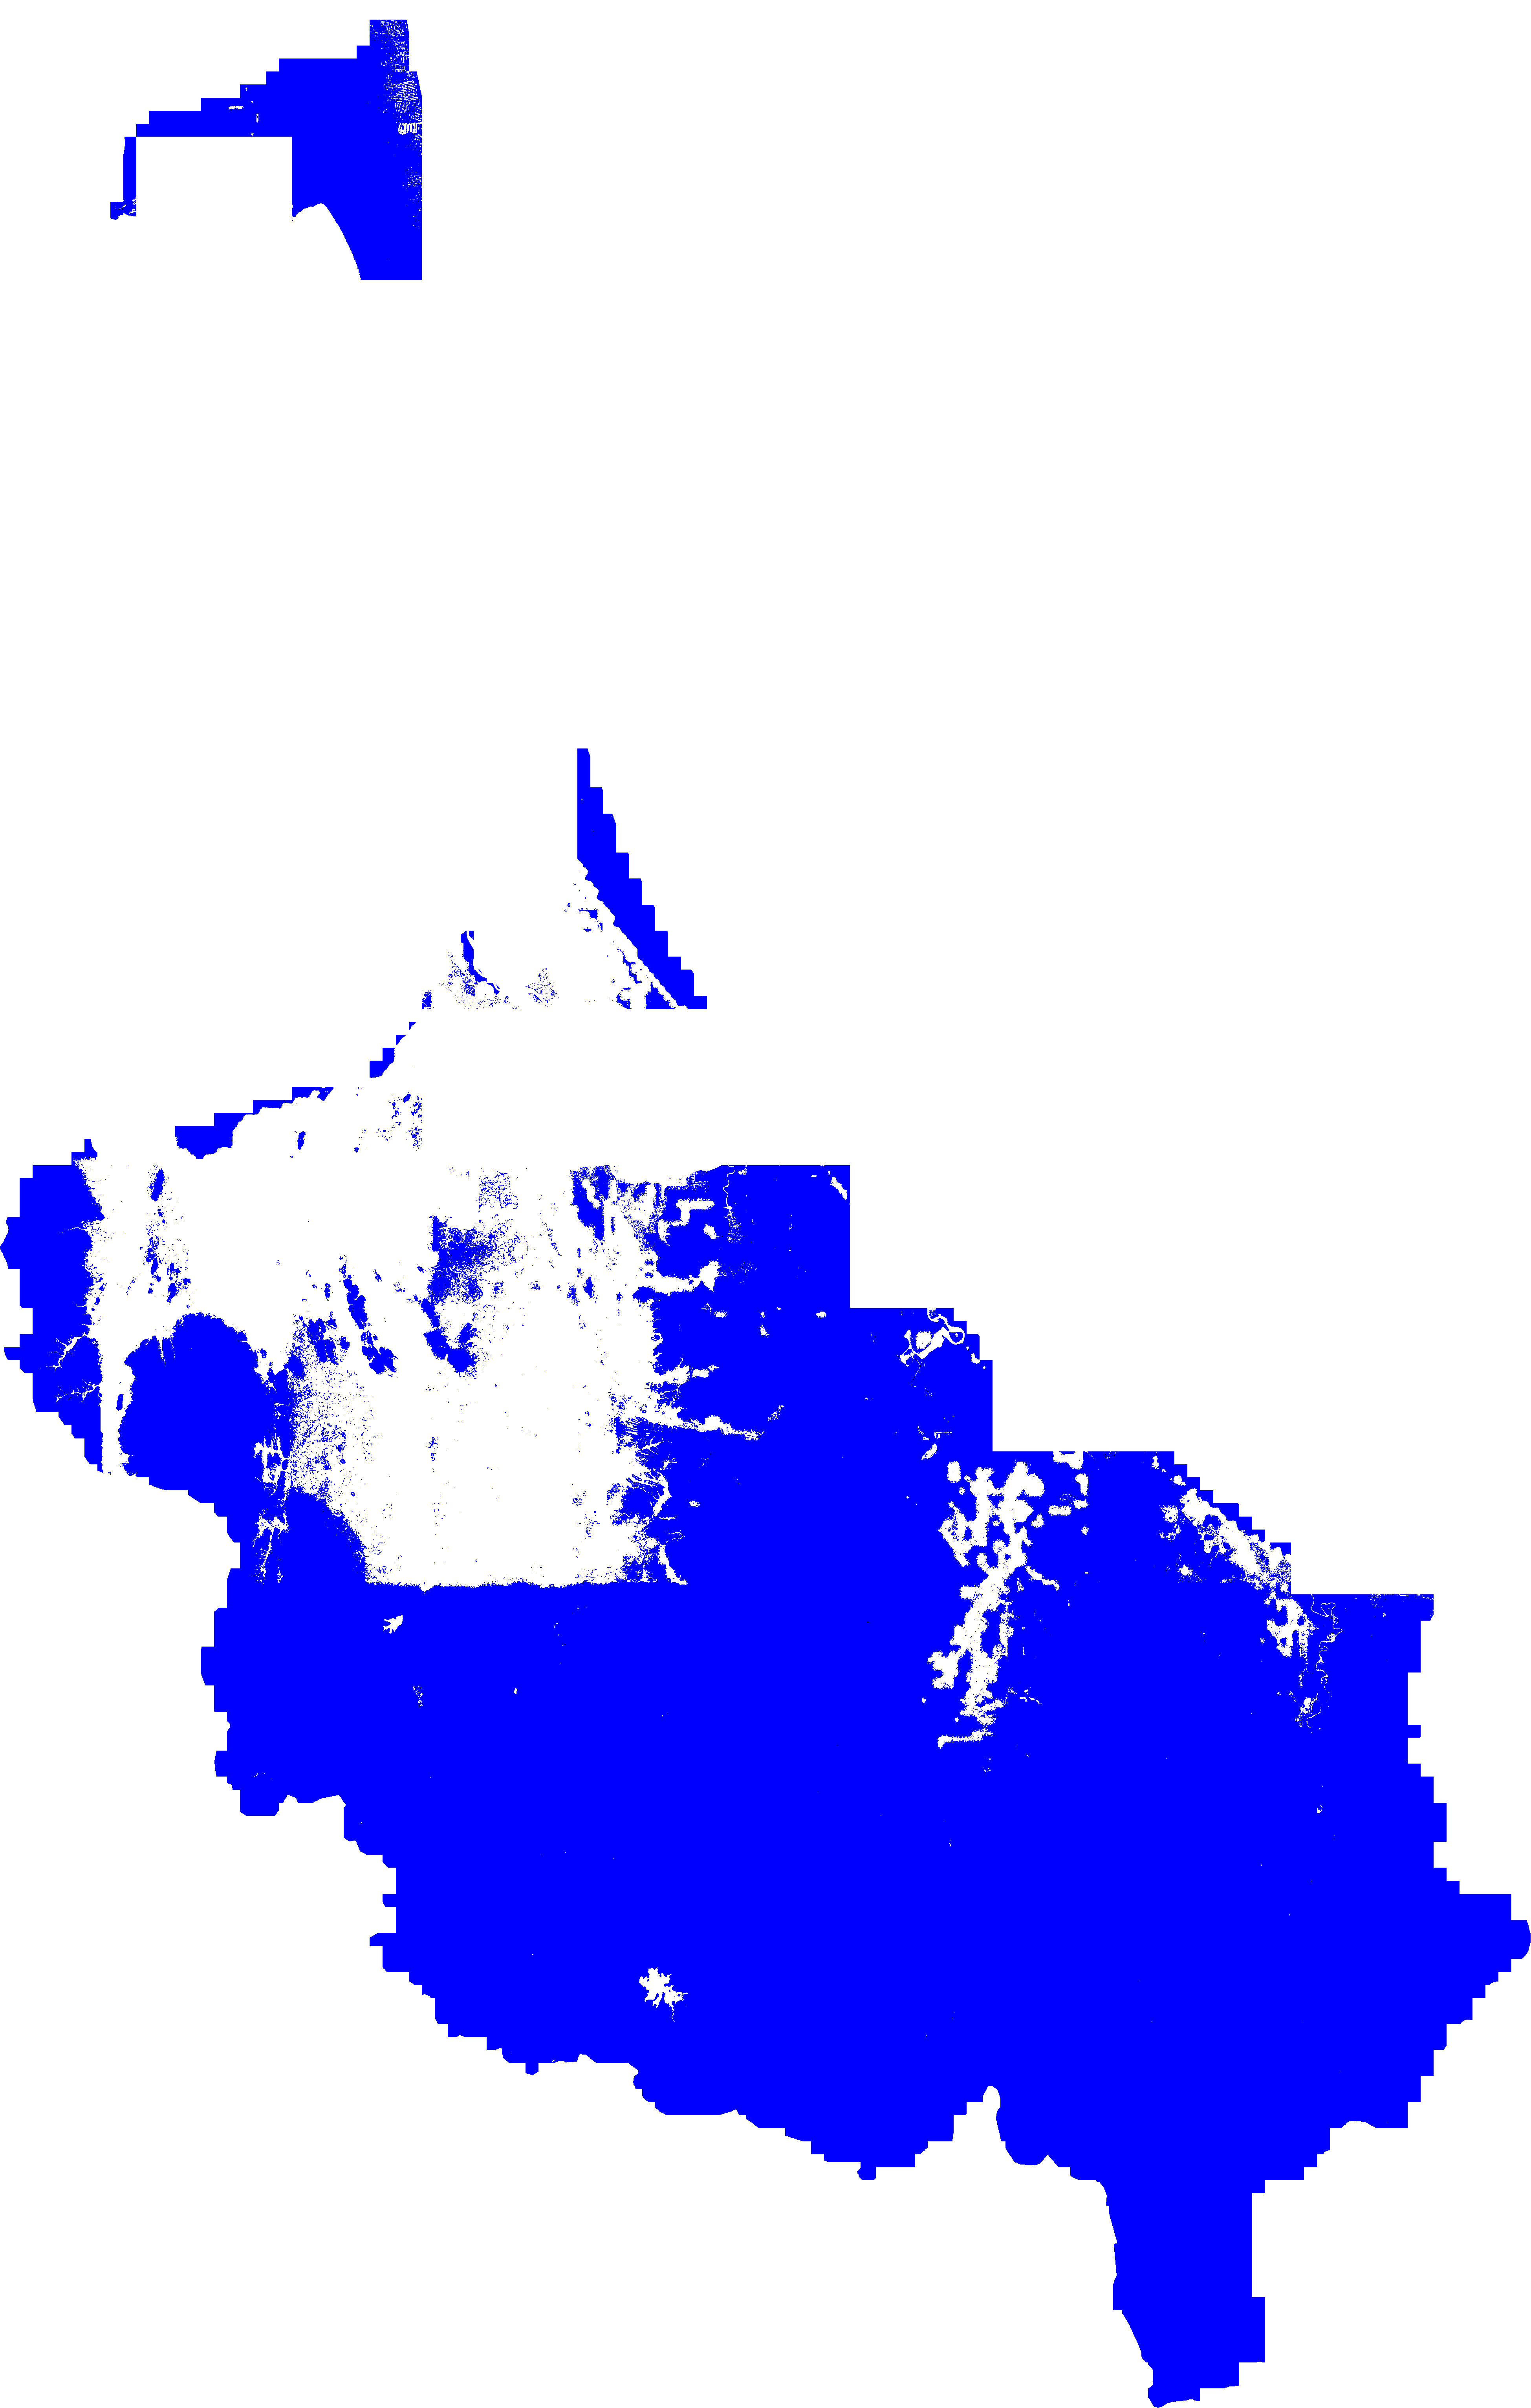
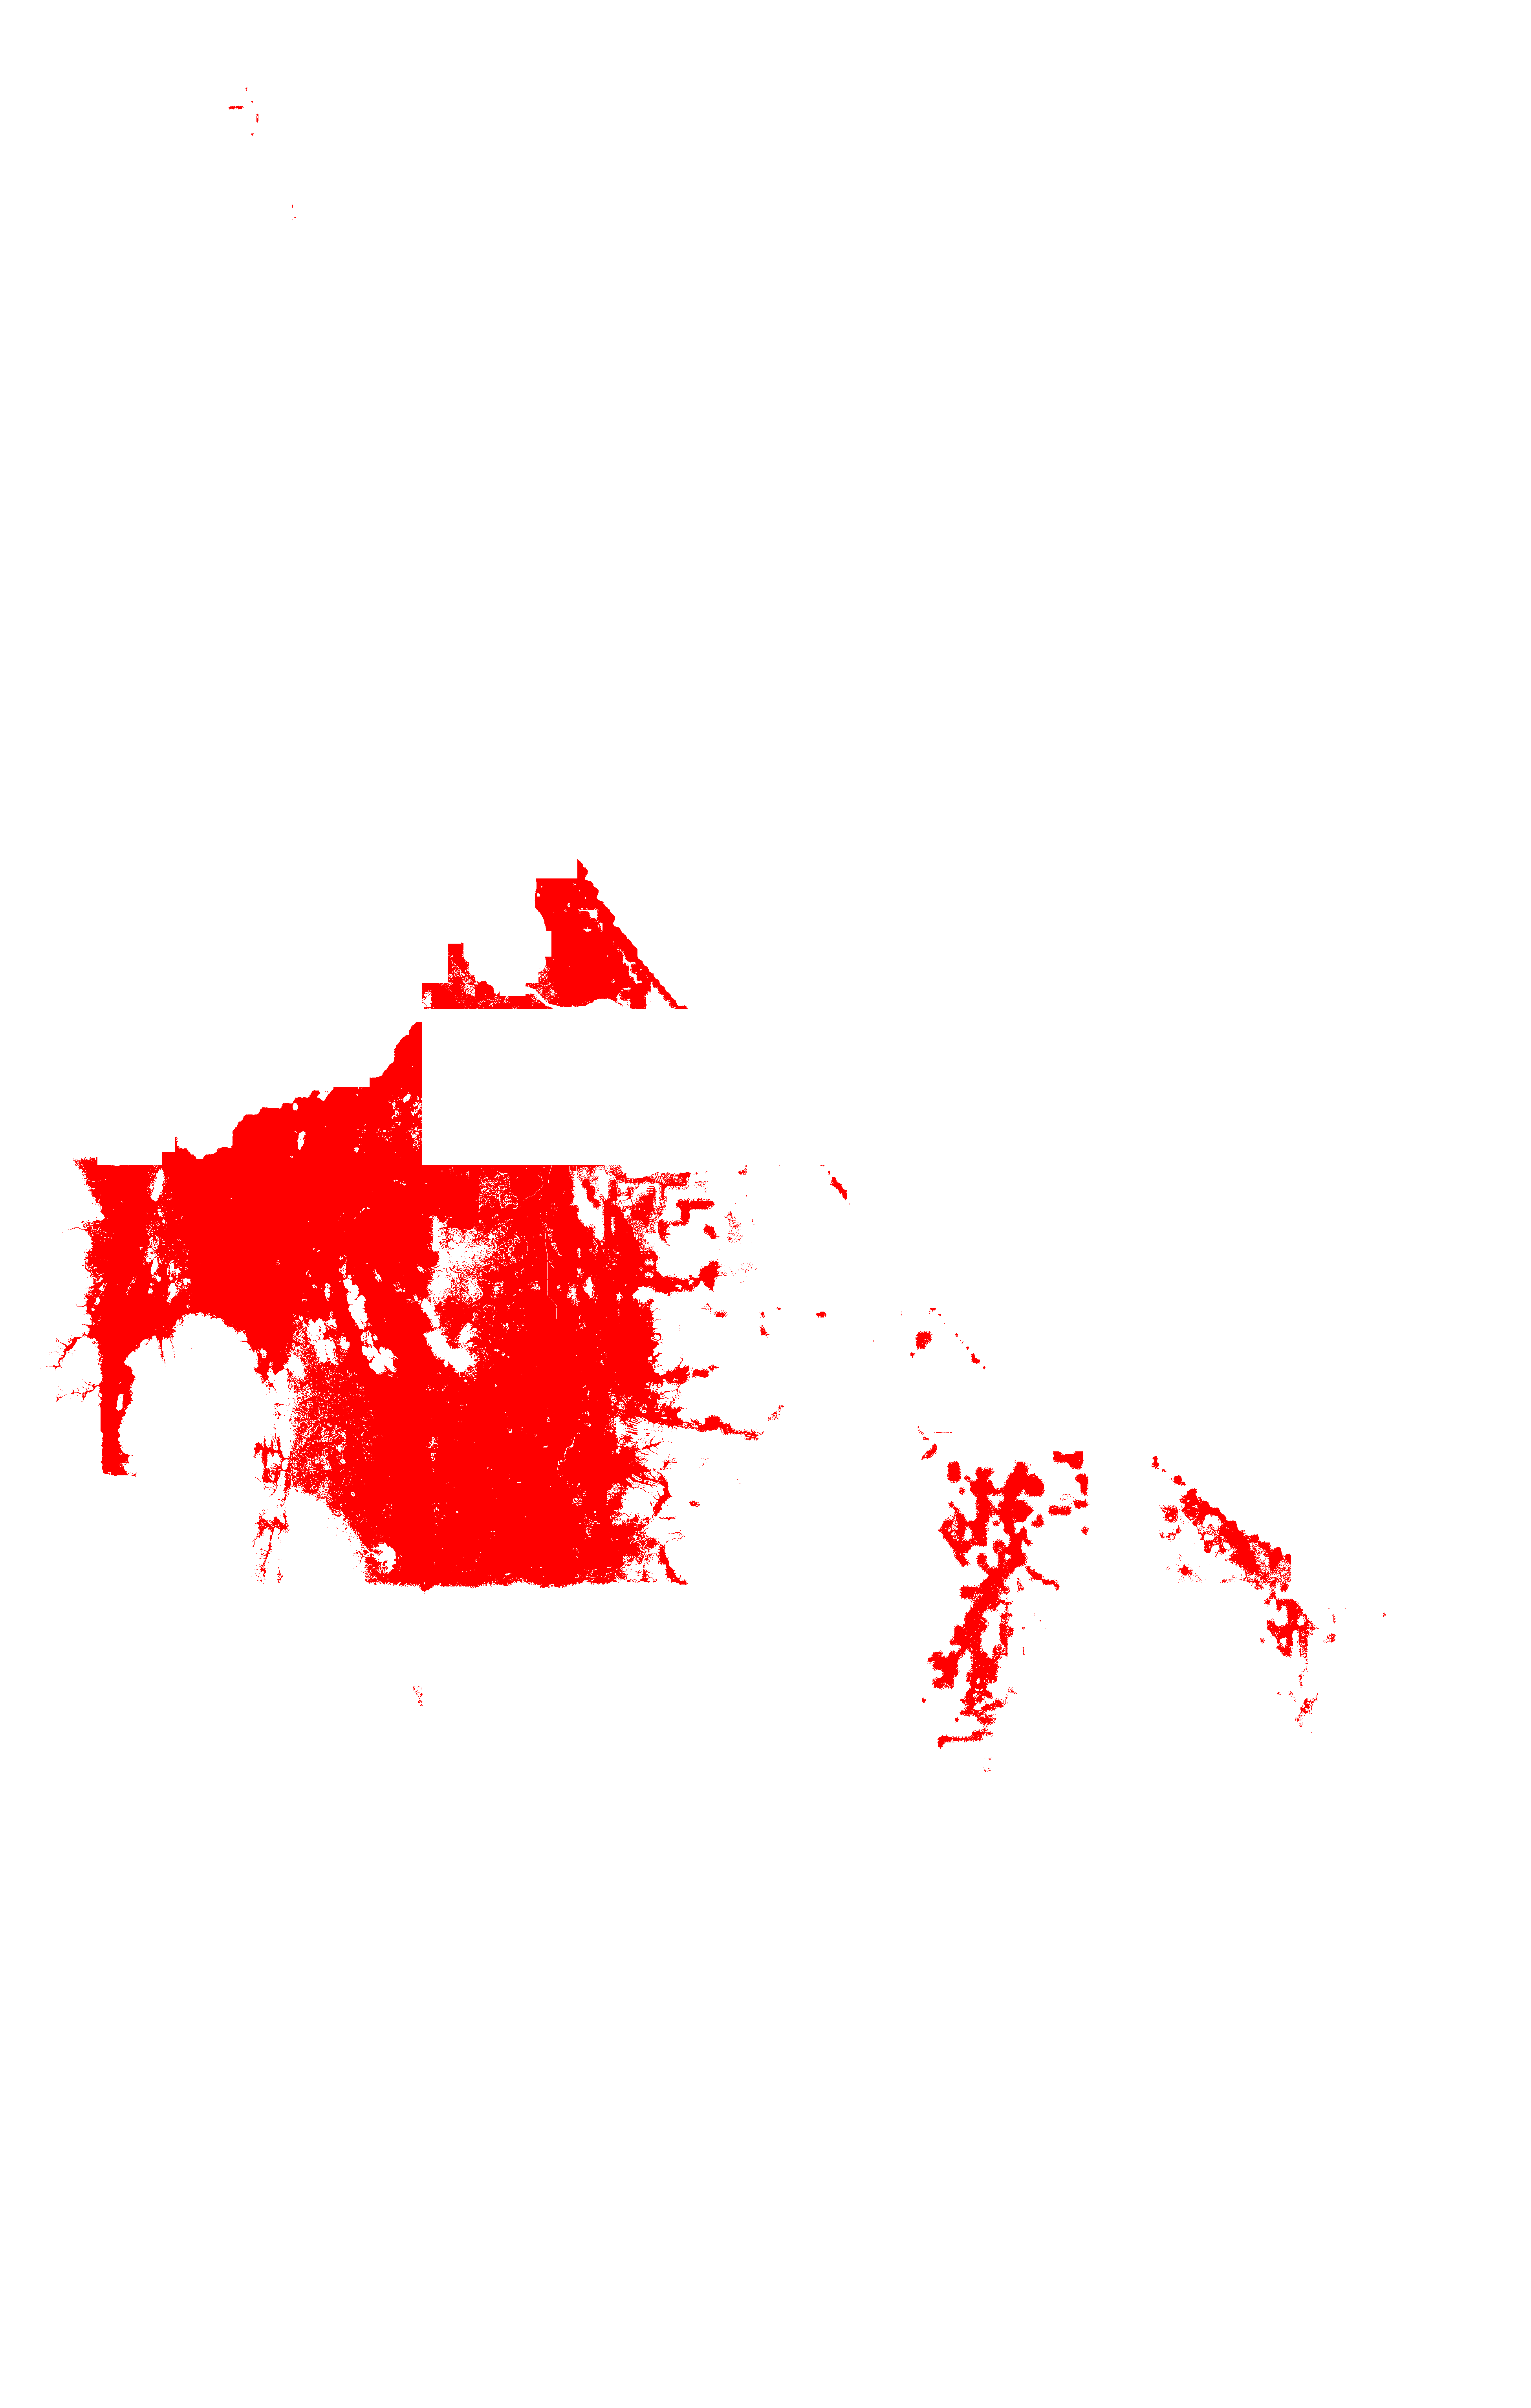
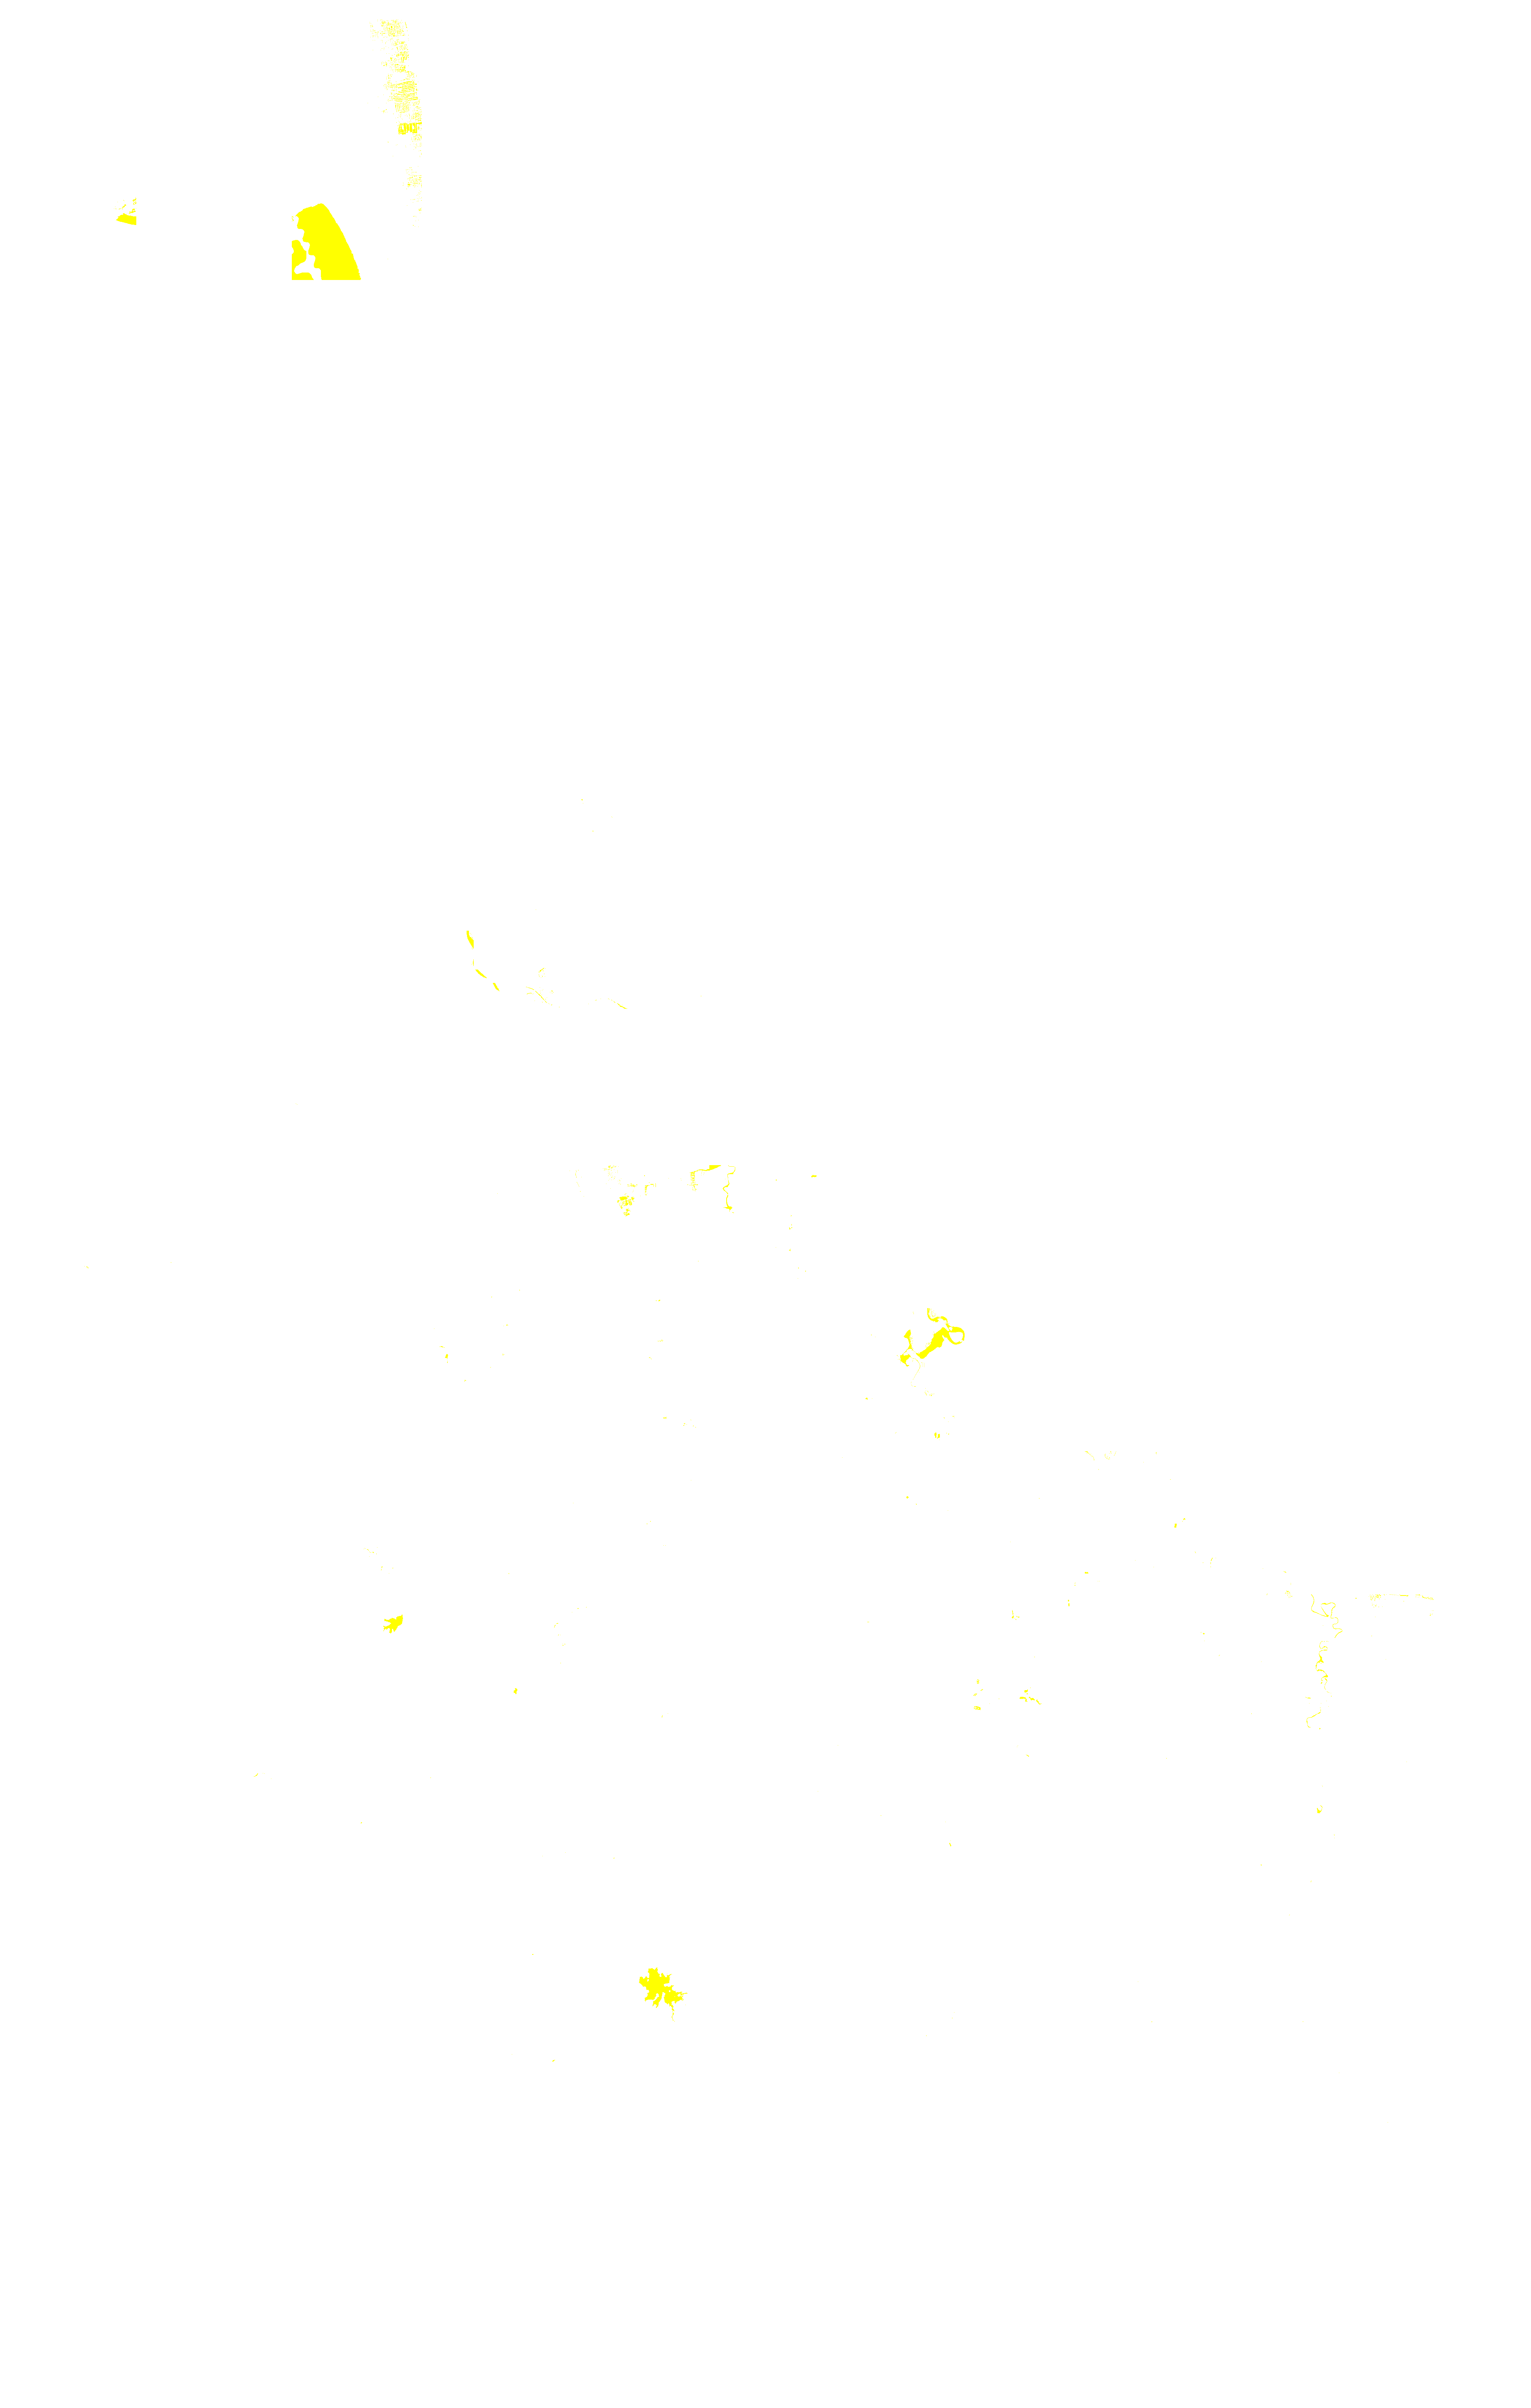

In [22]:
# =========================
# 1. Import
# =========================
import numpy as np
import rasterio
from rasterio.enums import Resampling
import folium

# =========================
# 2. PATH
# =========================
base_path = "/content/drive/MyDrive/LAB4/"
flood_path = base_path + "Flood_Base.tif"
jrc_path = base_path + "JRC_Occurrence_Songkhla.tif"

# =========================
# 3. โหลด flood_base
# =========================
with rasterio.open(flood_path) as src:
    flood_base = src.read(1)
    bounds = src.bounds

# =========================
# 4. โหลด JRC
# =========================
def load_match(path, ref_shape):
    with rasterio.open(path) as src:
        data = src.read(
            1,
            out_shape=ref_shape,
            resampling=Resampling.bilinear
        )
    return data

jrc = load_match(jrc_path, flood_base.shape)

# =========================
# 5. Threshold
# =========================
threshold = np.nanpercentile(flood_base, 80)

# =========================
# 6. Compare
# =========================
compare = np.zeros_like(flood_base)

compare[(flood_base > threshold) & (jrc > 50)] = 1  # TP
compare[(flood_base <= threshold) & (jrc <= 50)] = 2  # TN
compare[(flood_base > threshold) & (jrc <= 50)] = 3  # FP
compare[(flood_base <= threshold) & (jrc > 50)] = 4  # FN

# =========================
# 7. Mask
# =========================
mask = np.isfinite(flood_base)

# =========================
# 8. ฟังก์ชันสร้าง layer
# =========================
def create_layer(value, color):
    rgba = np.zeros((compare.shape[0], compare.shape[1], 4), dtype=np.uint8)
    rgba[(compare == value) & mask] = color
    rgba[~mask] = [0, 0, 0, 0]
    return rgba

tp_layer = create_layer(1, [0, 255, 0, 255])     # เขียว
tn_layer = create_layer(2, [0, 0, 255, 255])     # น้ำเงิน
fp_layer = create_layer(3, [255, 0, 0, 255])     # แดง
fn_layer = create_layer(4, [255, 255, 0, 255])   # เหลือง

# =========================
# 9. bounds
# =========================
minx, miny, maxx, maxy = bounds
map_bounds = [[miny, minx], [maxy, maxx]]

# =========================
# 10. Map
# =========================
m = folium.Map(location=[7.2, 100.6], zoom_start=8)

# เพิ่ม layer แต่ละประเภท
folium.raster_layers.ImageOverlay(
    image=tp_layer,
    bounds=map_bounds,
    name="TP (Flood Correct)",
    opacity=1
).add_to(m)

folium.raster_layers.ImageOverlay(
    image=tn_layer,
    bounds=map_bounds,
    name="TN (Non-Flood Correct)",
    opacity=1
).add_to(m)

folium.raster_layers.ImageOverlay(
    image=fp_layer,
    bounds=map_bounds,
    name="FP (Overestimate)",
    opacity=1
).add_to(m)

folium.raster_layers.ImageOverlay(
    image=fn_layer,
    bounds=map_bounds,
    name="FN (Missed Flood)",
    opacity=1
).add_to(m)

# =========================
# 11. Layer Control
# =========================
folium.LayerControl().add_to(m)

# =========================
# 12. Legend
# =========================
legend_html = """
<div style="
position: fixed;
bottom: 50px; left: 50px; width: 200px; height: 160px;
background-color: white; z-index:9999; font-size:14px;
border:2px solid grey; padding: 10px;">
<b>Validation Layers</b><br>
<span style="color:green;">■</span> TP<br>
<span style="color:blue;">■</span> TN<br>
<span style="color:red;">■</span> FP<br>
<span style="color:orange;">■</span> FN
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m

In [23]:
m.save("Validation_Map.html")

จากแผนที่ validation แบบ interactive ที่แยกชั้นข้อมูลออกเป็น TP, TN, FP และ FN พบว่าพื้นที่ส่วนใหญ่เป็น True Negative (TN) ซึ่งแสดงให้เห็นว่าโมเดลสามารถจำแนกพื้นที่ไม่ท่วมได้อย่างถูกต้องในวงกว้าง ขณะที่พื้นที่ True Positive (TP) ปรากฏในบางบริเวณที่สอดคล้องกับพื้นที่เสี่ยงน้ำท่วมจริง อย่างไรก็ตาม ยังพบพื้นที่ False Positive (FP) กระจายอยู่ในบางส่วน ซึ่งสะท้อนว่าโมเดลมีแนวโน้มประเมินน้ำท่วมเกินจริงในบางพื้นที่ และพื้นที่ False Negative (FN) ที่มีอยู่แสดงถึงบริเวณที่โมเดลไม่สามารถตรวจจับน้ำท่วมจริงได้ครบถ้วน ดังนั้น แม้โมเดลจะมีประสิทธิภาพโดยรวมอยู่ในระดับดี แต่ยังมีความไม่แน่นอนในบางพื้นที่ที่ควรได้รับการปรับปรุงเพิ่มเติม